# CLUSTERING

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_excel('EastWestAirlines.xlsx',sheet_name='data')

In [3]:
df.shape

(3999, 12)

In [4]:
df.head()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,1,28143,0,1,1,1,174,1,0,0,7000,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0
3,4,14776,0,1,1,1,500,1,0,0,6952,0
4,5,97752,0,4,1,1,43300,26,2077,4,6935,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3999 entries, 0 to 3998
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   ID#                3999 non-null   int64
 1   Balance            3999 non-null   int64
 2   Qual_miles         3999 non-null   int64
 3   cc1_miles          3999 non-null   int64
 4   cc2_miles          3999 non-null   int64
 5   cc3_miles          3999 non-null   int64
 6   Bonus_miles        3999 non-null   int64
 7   Bonus_trans        3999 non-null   int64
 8   Flight_miles_12mo  3999 non-null   int64
 9   Flight_trans_12    3999 non-null   int64
 10  Days_since_enroll  3999 non-null   int64
 11  Award?             3999 non-null   int64
dtypes: int64(12)
memory usage: 375.0 KB


In [6]:
df.describe()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
count,3999.000000,3.999000e+03,3999.000000,3999.000000,3999.000000,3999.000000,3999.000000,3999.00000,3999.000000,3999.000000,3999.00000,3999.000000
mean,2014.819455,7.360133e+04,144.114529,2.059515,1.014504,1.012253,17144.846212,11.60190,460.055764,1.373593,4118.55939,0.370343
std,1160.764358,1.007757e+05,773.663804,1.376919,0.147650,0.195241,24150.967826,9.60381,1400.209171,3.793172,2065.13454,0.482957
min,1.000000,0.000000e+00,0.000000,1.000000,1.000000,1.000000,0.000000,0.00000,0.000000,0.000000,2.00000,0.000000
25%,1010.500000,1.852750e+04,0.000000,1.000000,1.000000,1.000000,1250.000000,3.00000,0.000000,0.000000,2330.00000,0.000000
50%,2016.000000,4.309700e+04,0.000000,1.000000,1.000000,1.000000,7171.000000,12.00000,0.000000,0.000000,4096.00000,0.000000
75%,3020.500000,9.240400e+04,0.000000,3.000000,1.000000,1.000000,23800.500000,17.00000,311.000000,1.000000,5790.50000,1.000000
max,4021.000000,1.704838e+06,11148.000000,5.000000,3.000000,5.000000,263685.000000,86.00000,30817.000000,53.000000,8296.00000,1.000000


In [7]:
### missing values
df.isnull().sum()

ID#                  0
Balance              0
Qual_miles           0
cc1_miles            0
cc2_miles            0
cc3_miles            0
Bonus_miles          0
Bonus_trans          0
Flight_miles_12mo    0
Flight_trans_12      0
Days_since_enroll    0
Award?               0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

<Axes: >

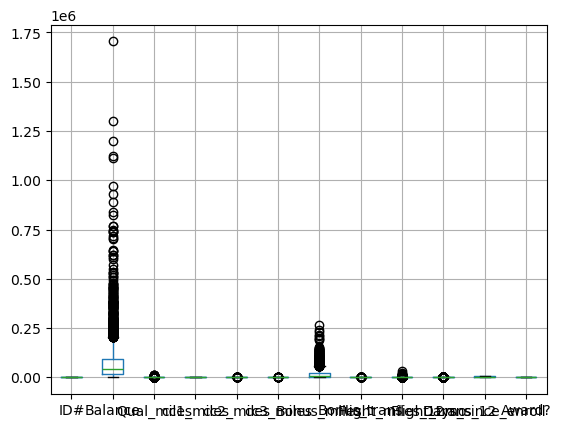

In [9]:
df.boxplot()

In [10]:
### outlier capping
def outlier_capping(df,column):
    Q1= df[column].quantile(0.25)
    Q3= df[column].quantile(0.75)
    IQR= Q3-Q1
    lower_extreme= Q1-1.5*IQR
    upper_extreme= Q3+1.5*IQR
    df[column]= df[column].apply(lambda x: lower_extreme if x<lower_extreme else upper_extreme if x>upper_extreme else x)
for col in df.select_dtypes(['int','float']).columns:
    outlier_capping(df,col)

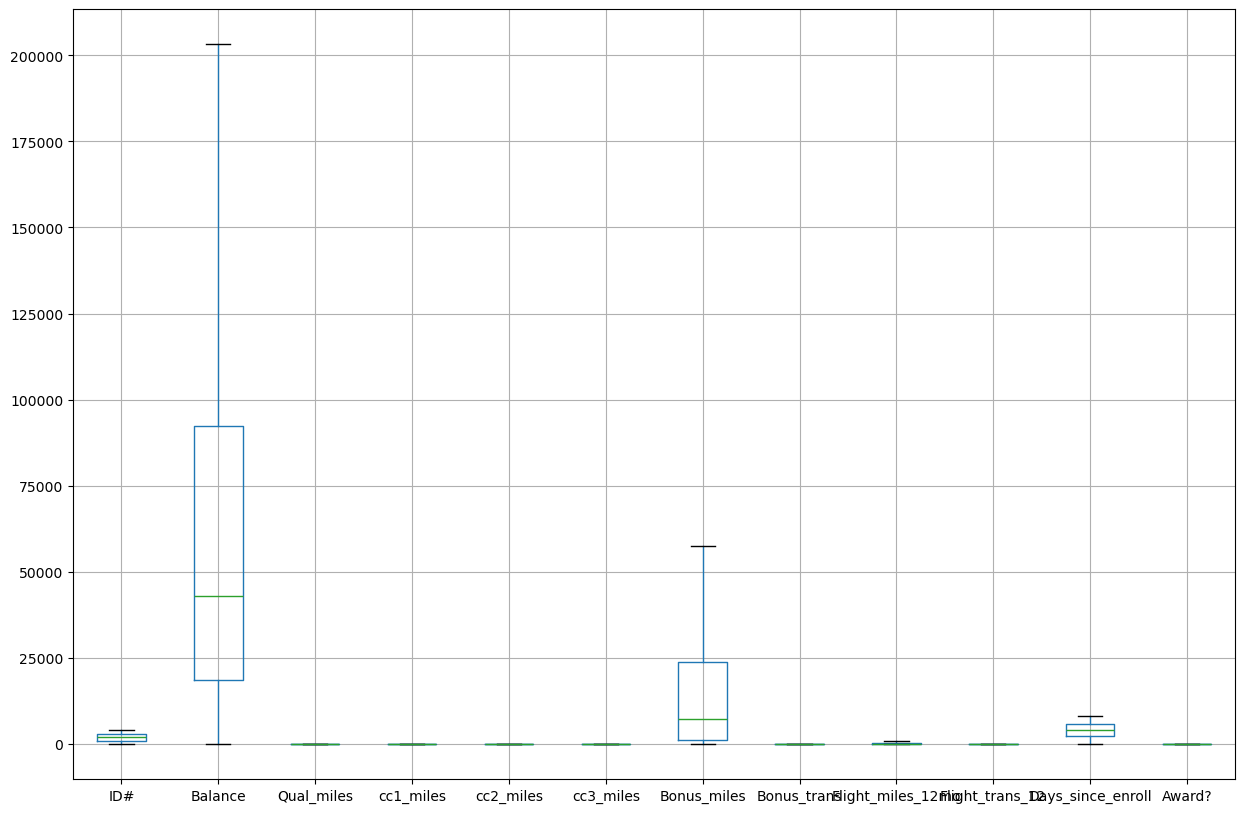

In [11]:
plt.figure(figsize=(15,10))
df.boxplot()
plt.show()

In [12]:
corr=df.corr()
corr

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
ID#,1.000000,-0.269374,NaN,-0.224465,NaN,NaN,-0.210868,-0.156118,-0.083917,-0.082887,-0.964988,-0.177901
Balance,-0.269374,1.000000,NaN,0.446510,NaN,NaN,0.494422,0.409017,0.297045,0.295565,0.286143,0.170678
Qual_miles,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cc1_miles,-0.224465,0.446510,NaN,1.000000,NaN,NaN,0.912531,0.627786,0.098786,0.087618,0.230849,0.335457
cc2_miles,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cc3_miles,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Bonus_miles,-0.210868,0.494422,NaN,0.912531,NaN,NaN,1.000000,0.663558,0.205801,0.193669,0.217320,0.394061
Bonus_trans,-0.156118,0.409017,NaN,0.627786,NaN,NaN,0.663558,1.000000,0.310543,0.308518,0.170308,0.337444
Flight_miles_12mo,-0.083917,0.297045,NaN,0.098786,NaN,NaN,0.205801,0.310543,1.000000,0.942734,0.095019,0.293119
Flight_trans_12,-0.082887,0.295565,NaN,0.087618,NaN,NaN,0.193669,0.308518,0.942734,1.000000,0.091898,0.300085


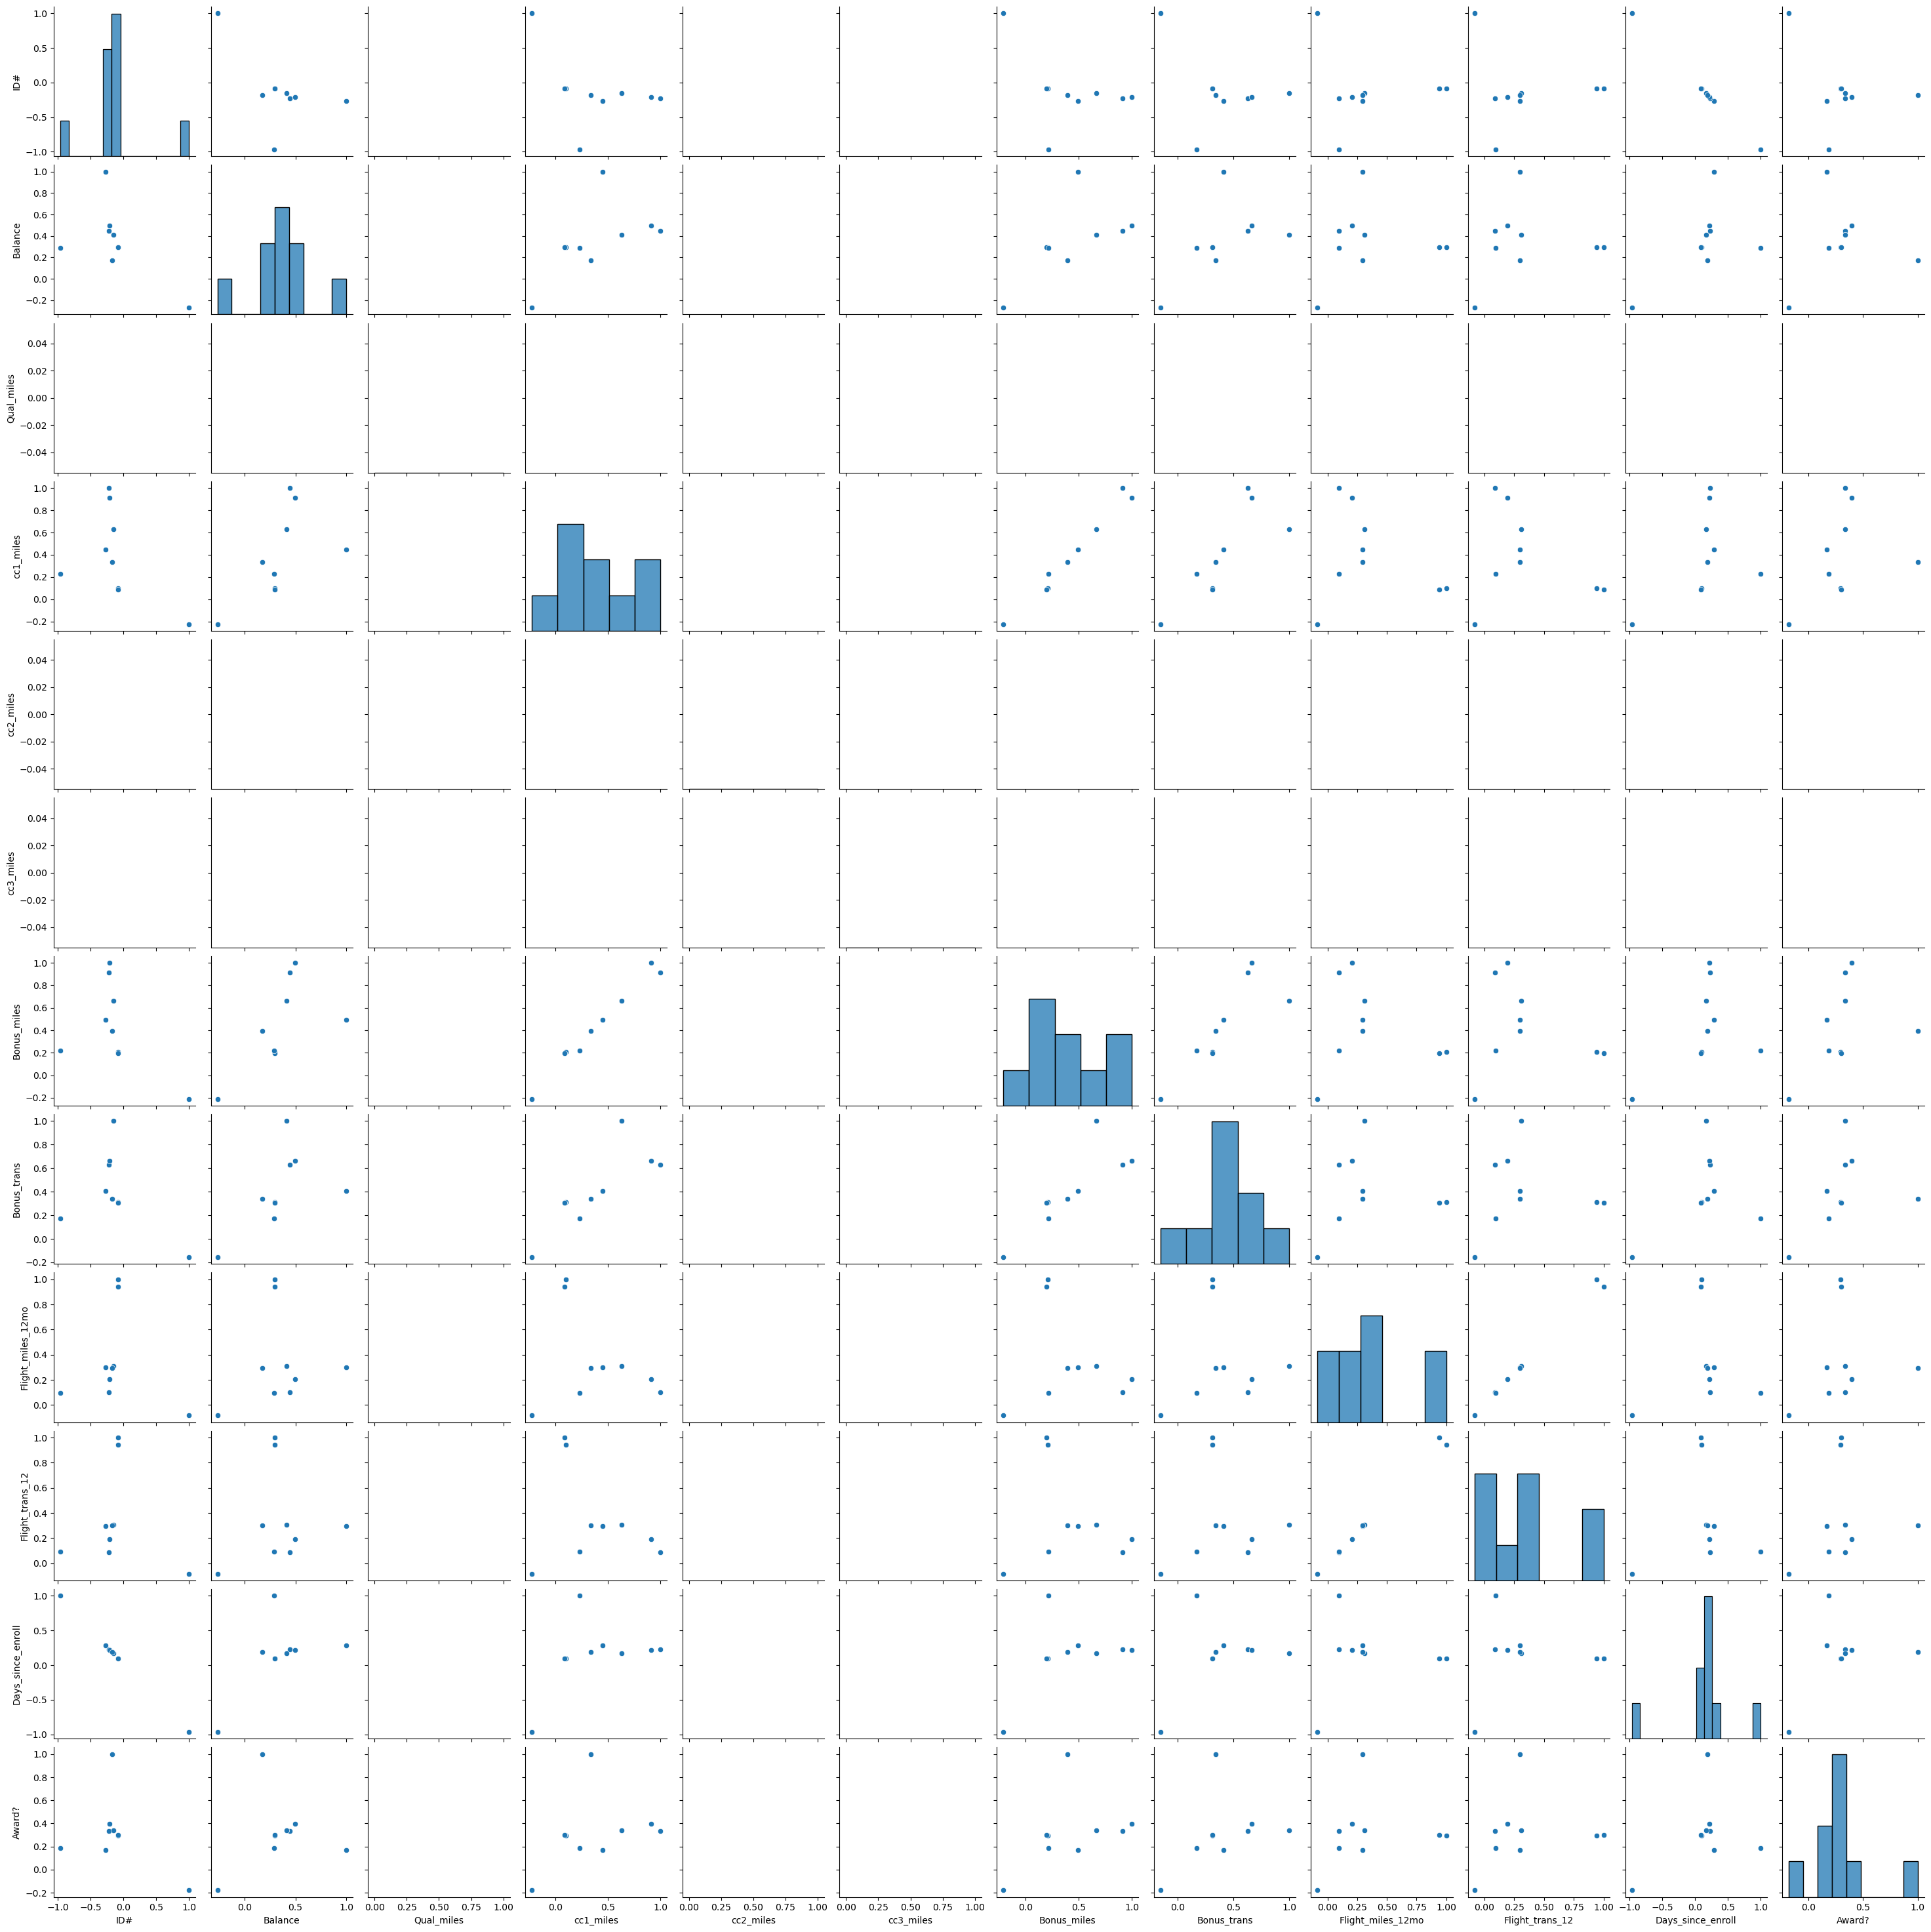

In [13]:
#correlation of the data using pairplot
sns.pairplot(corr)   
plt.show()

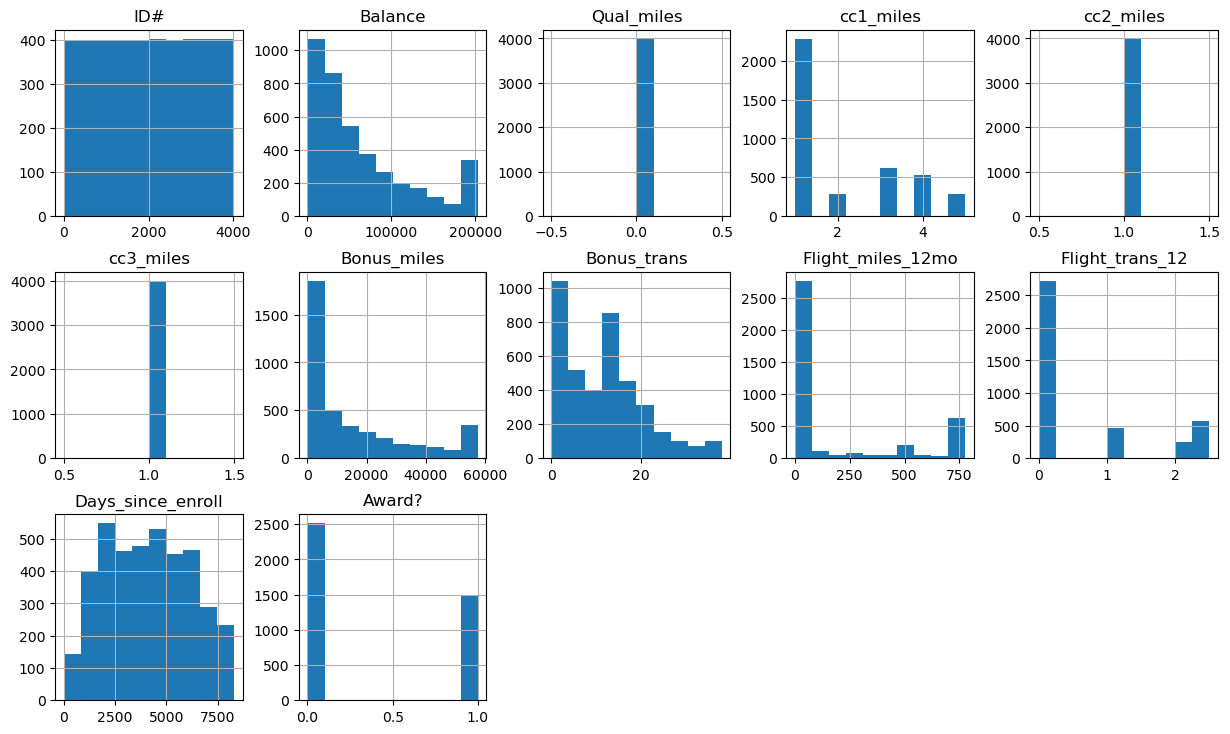

In [14]:
df.hist(figsize=(15,15),layout=(5,5)) 
plt.show()
#visualization using histogram to understand the dataset deeper     

In [15]:
df.columns

Index(['ID#', 'Balance', 'Qual_miles', 'cc1_miles', 'cc2_miles', 'cc3_miles',
       'Bonus_miles', 'Bonus_trans', 'Flight_miles_12mo', 'Flight_trans_12',
       'Days_since_enroll', 'Award?'],
      dtype='object')

In [16]:
x=df.drop(['ID#'], axis=1) 

In [17]:
x.columns

Index(['Balance', 'Qual_miles', 'cc1_miles', 'cc2_miles', 'cc3_miles',
       'Bonus_miles', 'Bonus_trans', 'Flight_miles_12mo', 'Flight_trans_12',
       'Days_since_enroll', 'Award?'],
      dtype='object')

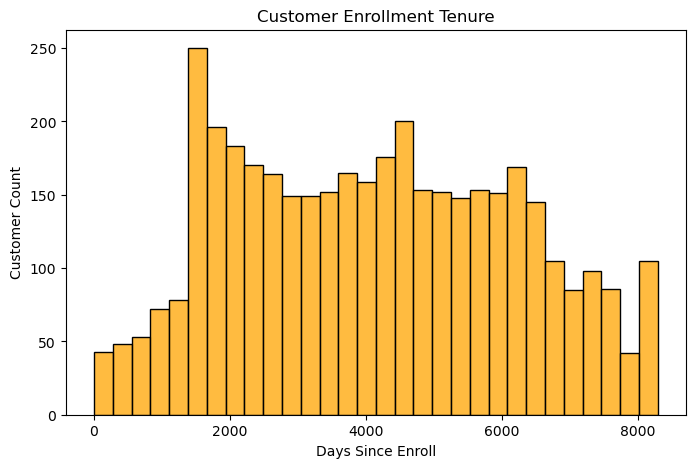

In [18]:
plt.figure(figsize=(8,5))
sns.histplot(df['Days_since_enroll'], bins=30, color='orange')
plt.title("Customer Enrollment Tenure")
plt.xlabel("Days Since Enroll")
plt.ylabel("Customer Count")
plt.show()

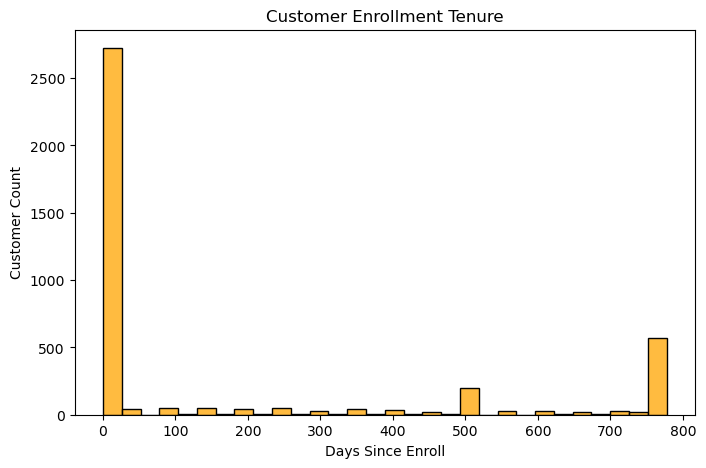

In [19]:
plt.figure(figsize=(8,5))
sns.histplot(df['Flight_miles_12mo'], bins=30, color='orange')
plt.title("Customer Enrollment Tenure")
plt.xlabel("Days Since Enroll")
plt.ylabel("Customer Count")
plt.show()

In [20]:
#implementing kmeans unsupervised algorithm and evaluating
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [49]:
wcss=[]
for i in range(2,11):
  kmeans=KMeans(n_clusters=i,random_state=42)
  kmeans.fit(x)
  wcss.append(kmeans.inertia_)

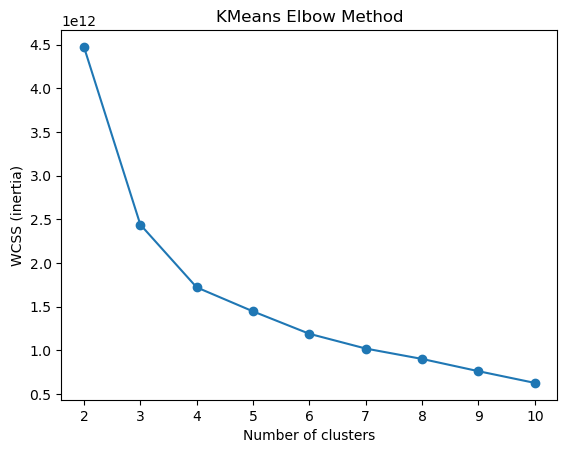

In [50]:
# using elbow curve method for optimal k value
plt.plot(range(2,11),wcss,marker='o') 
plt.title('KMeans Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS (inertia)')
plt.show()
     

In [51]:
# applying KMeans

kmeans = KMeans(n_clusters=3,random_state=42)
kmeans_labels = kmeans.fit_predict(x)

print('silhouette score (k-means):',silhouette_score(x,kmeans_labels))

silhouette score (k-means): 0.5452510534150188


In [52]:
#hierarchical clustering
from scipy.cluster.hierarchy import dendrogram,linkage

In [53]:
# dendrogram

linked = linkage(x,method='ward')

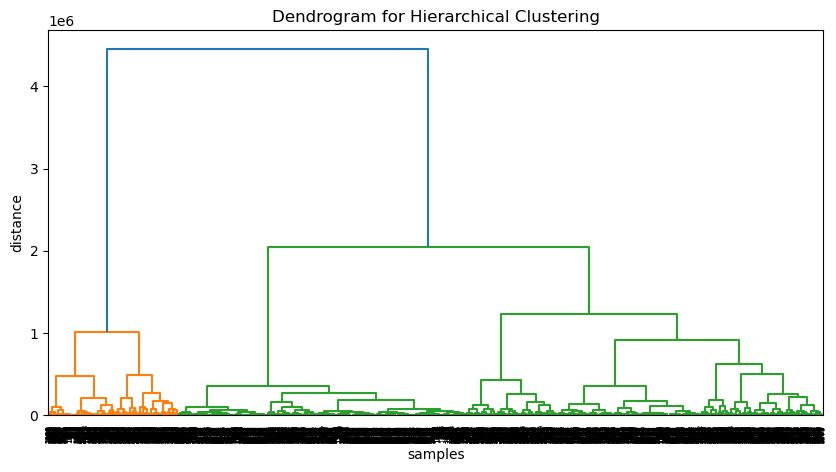

In [55]:
plt.figure(figsize=(10,5))
dendrogram(linked)
plt.title('Dendrogram for Hierarchical Clustering')
plt.xlabel('samples')
plt.ylabel('distance')
plt.show()

In [48]:
# applying hierarchical clustering

hierarchical = AgglomerativeClustering(n_clusters=3,linkage='ward')
hier_labels = hierarchical.fit_predict(x)

print('Silhouette score (Hierarchical):',silhouette_score(x,hier_labels))

Silhouette score (Hierarchical): 0.43234830591260076


In [30]:
#DBSCAN algorithm
from sklearn.cluster import DBSCAN


In [56]:
dbscan = DBSCAN(eps=0.5, min_samples=5)
db_labels = dbscan.fit_predict(x)

In [58]:
# applying DBSCAN

n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
print('DBSCAN cluster:',n_clusters)

if n_clusters > 1:
    score = silhouette_score(x,db_labels)
    print('silhouette score (DBSCAN):',score)
else:
    print('Silhouette score not applicables (only one cluster found)')

DBSCAN cluster: 0
Silhouette score not applicables (only one cluster found)


In [60]:
### Cluster Analysis and Interpretation
x['KMeans_Cluster'] = kmeans_labels
x['Hierarchical_Cluster'] = hier_labels
x['DBSCAN_Cluster'] = db_labels

In [63]:
# mean

# kmeans clusters
print(x.groupby('KMeans_Cluster').mean(numeric_only=True))

# hierarchical clusters
print(x.groupby('Hierarchical_Cluster').mean(numeric_only=True))


# dbscan clusters
print(x[x['DBSCAN_Cluster'] != -1].groupby('DBSCAN_Cluster').mean(numeric_only=True))

                      Balance  Qual_miles  cc1_miles  cc2_miles  cc3_miles  \
KMeans_Cluster                                                               
0                85639.688132         0.0   2.677093        1.0        1.0   
1                23688.817947         0.0   1.503883        1.0        1.0   
2               180151.100168         0.0   3.097643        1.0        1.0   

                 Bonus_miles  Bonus_trans  Flight_miles_12mo  Flight_trans_12  \
KMeans_Cluster                                                                  
0               23098.462971    14.770009         229.493560         0.746090   
1                7664.802416     8.355047         114.251941         0.389991   
2               31569.816077    17.590909         332.910774         1.095118   

                Days_since_enroll    Award?  Hierarchical_Cluster  \
KMeans_Cluster                                                      
0                     4399.306348  0.413983              0.074517

In [64]:
# count

# kmeans cluster
print('KMeans cluster counts:')
print(x['KMeans_Cluster'].value_counts())

# hierarchical cluster
print('Hierarchical cluster counts:')
print(x['Hierarchical_Cluster'].value_counts())

# dbscan cluster
print('DBSCAN cluster counts:')
print(x['DBSCAN_Cluster'].value_counts())

KMeans cluster counts:
KMeans_Cluster
1    2318
0    1087
2     594
Name: count, dtype: int64
Hierarchical cluster counts:
Hierarchical_Cluster
0    1841
2    1486
1     672
Name: count, dtype: int64
DBSCAN cluster counts:
DBSCAN_Cluster
-1    3999
Name: count, dtype: int64


In [65]:
# k-means

# cluster 0 : moderate balance & miles, medium loyalty (regular flyers)
# cluster 1 : low balance & activity, least loyal (new/inactive customers)
# cluster 2 : high balance & miles, very loyal (permium customers)

#hierarchical

# cluster 0 : low activity group
# cluster 1 : moderate flyers with average loyalty
# cluster 2 : high-value, long-term loyal customers

#dbscan

# all points marked as noise : parameters too strict (increase eps to get clusters)

# overall:
# data naturally forms 3 groups - low, medium, and high-value customers

In [66]:
### visualization
from sklearn.decomposition import PCA

In [67]:
pca = PCA(n_components=2)
X = pca.fit_transform(x)

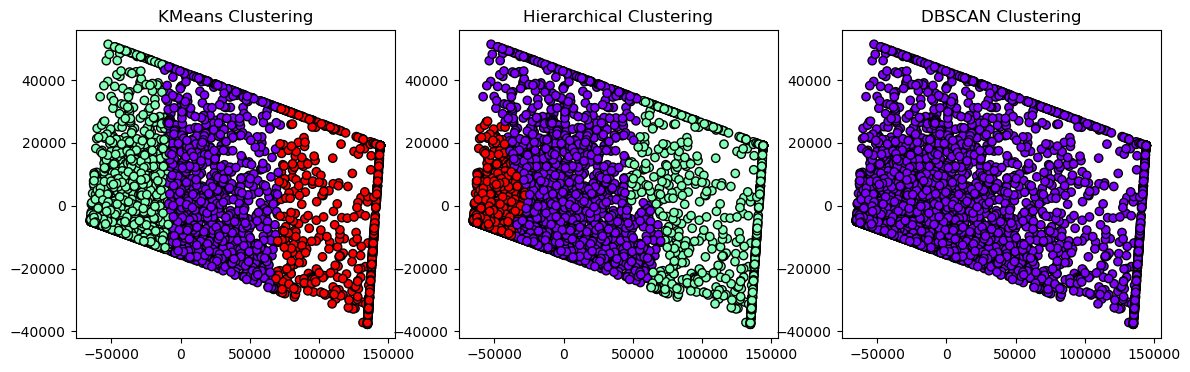

In [70]:
plt.figure(figsize=(14,4))

# kmeans
plt.subplot(1,3,1)
plt.scatter(X[:,0],X[:,1],c=kmeans_labels,cmap='rainbow',edgecolor='black')
plt.title('KMeans Clustering')

# hierarchical
plt.subplot(1,3,2)
plt.scatter(X[:,0],X[:,1],c=hier_labels,cmap='rainbow',edgecolor='black')
plt.title('Hierarchical Clustering')

# dbscan
plt.subplot(1,3,3)
plt.scatter(X[:,0],X[:,1],c=db_labels,cmap='rainbow',edgecolor='black')
plt.title('DBSCAN Clustering')

plt.show()